In [1]:
import os
import re
import json
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import datetime

import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib.colors import ListedColormap


from patsy import dmatrices
import bambi as bmb
import arviz as az
from scipy.stats import chi2
import statsmodels.api as sm
import matplotlib.pyplot as plt
from IPython.display import display
import statsmodels.formula.api as smf
from scipy.stats import chi2_contingency
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.outliers_influence import variance_inflation_factor

from util import *

sns.set_palette('colorblind')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

### initialise vars

In [2]:
msnbc_urls = [
    "https://www.instagram.com/msnbc/reel/DQz6GiKkqD-/",
    "https://www.instagram.com/msnbc/reel/DQzvigyiu3R/",
    "https://www.instagram.com/msnbc/reel/DQzaxBeisq2/",
    "https://www.instagram.com/msnbc/reel/DQzOhJyil7B/",
    "https://www.instagram.com/msnbc/reel/DQx_MsXDdqz/",
    "https://www.instagram.com/reel/DQx6d6TDFvD/",
    "https://www.instagram.com/reel/DQxz17nkXAu/",
    "https://www.instagram.com/reel/DQxxwsjEQxy/",
    "https://www.instagram.com/reel/DQxf5uvERD0/",
    "https://www.instagram.com/reel/DQxc21kkqwR/",
]

huffpost_urls = [
    "https://www.instagram.com/huffpost/reel/DQzSuMQARR0/",
    "https://www.instagram.com/huffpost/p/DQxLW-PEns-/",
    "https://www.instagram.com/huffpost/reel/DQxARFuAbt-/",
    "https://www.instagram.com/huffpost/reel/DQw6Qa_kWgY/",
    "https://www.instagram.com/huffpost/reel/DQw5_xHkWod/",
    "https://www.instagram.com/huffpost/reel/DQwbCxQjQNQ/",
    "https://www.instagram.com/huffpost/p/DQu2w59E9t-/",
    "https://www.instagram.com/huffpost/reel/DQvEm2FDCmz/",
    "https://www.instagram.com/huffpost/p/DQuw7U7D322/",
    "https://www.instagram.com/p/DQujjUrk61E/"
]

cnn_urls = [
    "https://www.instagram.com/reel/DQ0VgDjjx7K/",
    # "https://www.instagram.com/p/DQ0LWj6jue3/",
    "https://www.instagram.com/reel/DQz7vqJiEUj/",
    "https://www.instagram.com/reel/DQznNr7gp1F/",
    "https://www.instagram.com/reel/DQzgXgPgPmN/",
    "https://www.instagram.com/reel/DQzNYM8ARN3/",
    "https://www.instagram.com/reel/DQzEp0pChCY/",
    "https://www.instagram.com/reel/DQy-AdiCcH_/",
    "https://www.instagram.com/reel/DQyzpQVjga4/",
    "https://www.instagram.com/reel/DQypWvmDoge/"
]

washingtonpost_urls = [
    "https://www.instagram.com/washingtonpost/p/DQ0JgL9DqcC/",
    "https://www.instagram.com/washingtonpost/p/DQz7wRODMr8/",
    "https://www.instagram.com/washingtonpost/p/DQzuD3fFJcu/",
    "https://www.instagram.com/washingtonpost/reel/DQzh-t0DSAJ/",
    "https://www.instagram.com/washingtonpost/reel/DQzgTDHAcKl/",
    "https://www.instagram.com/p/DQzZihPDiQv/",
    "https://www.instagram.com/reel/DQzSo12D1fJ/",
    "https://www.instagram.com/reel/DQzLtq3ARq3/",
    "https://www.instagram.com/p/DQxxk6BDvZh/",
    "https://www.instagram.com/p/DQxqaCpDcHC/"
]

forbes_urls = [
    "https://www.instagram.com/forbes/p/DQ0Ck-lgUxt/",
    "https://www.instagram.com/forbes/p/DQz0444AWAd/",
    "https://www.instagram.com/forbes/p/DQzgP9_gcjC/",
    "https://www.instagram.com/p/DQzUOiGAblX/",
    "https://www.instagram.com/p/DQzLpqJDxMD/",
    "https://www.instagram.com/p/DQzFWzxkT-c/",
    "https://www.instagram.com/p/DQxdypCDPF2/",
    "https://www.instagram.com/p/DQxOpmbkn_b/",
    "https://www.instagram.com/p/DQxFjBJj4gS/",
    "https://www.instagram.com/p/DQxElAzD6aK/"
]

thehill_urls = [
    "https://www.instagram.com/thehill/p/DQzfVDcE3YB/",
    "https://www.instagram.com/thehill/p/DQxg1ufkeqR/",
    "https://www.instagram.com/thehill/reel/DQxViLFEdQ5/",
    "https://www.instagram.com/thehill/p/DQw1LZxEwrn/",
    "https://www.instagram.com/thehill/p/DQwgkZxD2Ug/",
    "https://www.instagram.com/thehill/reel/DQvAK9hEeWU/",
    "https://www.instagram.com/thehill/p/DQunQLokn-7/",
    "https://www.instagram.com/thehill/reel/DQuNa5zEeiR/",
    "https://www.instagram.com/thehill/p/DQt9lxsjumG/",
    "https://www.instagram.com/reel/DQrpC35EXqn/"
]

washingtontimes_urls = [
    "https://www.instagram.com/washtimes/p/DQz0CxJExjr/",
    "https://www.instagram.com/washtimes/p/DQzcWsGkg8C/",
    "https://www.instagram.com/washtimes/p/DQxHICQE_29/",
    "https://www.instagram.com/washtimes/p/DQw_V8sE6ZH/",
    "https://www.instagram.com/washtimes/p/DQw3jz6k0L6/",
    "https://www.instagram.com/washtimes/p/DQwvq-dktiv/",
    "https://www.instagram.com/washtimes/p/DQwn4b2EzCR/",
    "https://www.instagram.com/washtimes/p/DQwgGZ2jQck/",
    "https://www.instagram.com/washtimes/p/DQvCB1iEwBa/",
    "https://www.instagram.com/washtimes/reel/DQu5zA1CL3U/"
]

nypost_urls = [
    "https://www.instagram.com/p/DQ0Jd_SAc4Z/",
    "https://www.instagram.com/p/DQ0GBAngWyx/",
    "https://www.instagram.com/reel/DQ0ETkoDtLN/",
    "https://www.instagram.com/p/DQ0ClEugU1r/",
    "https://www.instagram.com/p/DQz_JRkAWr9/",
    "https://www.instagram.com/reel/DQz9kQIDZOc/",
    "https://www.instagram.com/p/DQz70tPAQTn/",
    "https://www.instagram.com/p/DQz4Y1Xgadc/",
    "https://www.instagram.com/reel/DQz2rWGEkpe/",
    "https://www.instagram.com/p/DQz09vagSe1/"
]

foxnews_urls = [
    "https://www.instagram.com/reel/DQ0V_qAEfwE/",
    "https://www.instagram.com/reel/DQ0UdiODE-2/",
    "https://www.instagram.com/reel/DQ0UNIZD3rv/",
    "https://www.instagram.com/reel/DQ0OfgWAswZ/",
    "https://www.instagram.com/reel/DQ0OAwCk91U/",
    "https://www.instagram.com/reel/DQ0GaXEjofE/",
    "https://www.instagram.com/reel/DQ0ClztkmYz/",
    "https://www.instagram.com/p/DQ0AYUTkvh4/",
    "https://www.instagram.com/p/DQz8ZTUjJ4s/",
    "https://www.instagram.com/reel/DQz8UW2j4TQ/"
]

breitbart_urls = [
    "https://www.instagram.com/p/DQ0P_UtDFLj/",
    "https://www.instagram.com/p/DQ0ImR1DaM0/",
    "https://www.instagram.com/p/DQz28XJkuQV/",
    "https://www.instagram.com/p/DQzkN12CUZQ/",
    "https://www.instagram.com/reel/DQzXuPOkgOo/",
    "https://www.instagram.com/p/DQzR5CjkQxS/",
    "https://www.instagram.com/p/DQzJCenDSPC/",
    "https://www.instagram.com/p/DQy1VfcETEi/",
    "https://www.instagram.com/reel/DQxZ3LCkvgh/",
    "https://www.instagram.com/p/DQxfi8JjVGb/"
]

news_urls = {
    'msnbc': msnbc_urls,
    'huffpost': huffpost_urls,
    'cnn': cnn_urls,
    'washingtonpost': washingtonpost_urls,
    'forbes': forbes_urls,
    'thehill': thehill_urls,
    'washingtontimes': washingtontimes_urls,
    'nypost': nypost_urls,
    'foxnews': foxnews_urls,
    'breitbart': breitbart_urls
}

In [3]:
peacock_urls = [
    'https://www.instagram.com/peacock/reel/DSEC7pojf3H/',
    'https://www.instagram.com/peacock/reel/DSEFSQJAGeV/',
    'https://www.instagram.com/peacock/p/DSD45vFgDBd/',
    'https://www.instagram.com/peacock/reel/DSDUvgsgLqk/',
    'https://www.instagram.com/belairpeacock/reel/DSDOHnBCS0t/',
    'https://www.instagram.com/nbc/reel/DSDOHj2kr00/',
    'https://www.instagram.com/spotify/reel/DSDN0oCDkGb/',
    'https://www.instagram.com/peacock/p/DSDAUdIgDUw/',
    'https://www.instagram.com/peacock/reel/DSBm_S8gC1p/',
    'https://www.instagram.com/peacock/reel/DSBZZEcgL4D/',
]

nytcooking_urls = [
    'https://www.instagram.com/nytcooking/reel/DSD_gy1DcX5/',
    'https://www.instagram.com/nytcooking/p/DSDwcgkk1qn/',
    'https://www.instagram.com/nytcooking/p/DSDitvpAZUH/',
    'https://www.instagram.com/nytcooking/p/DSDb1UoknQg/',
    'https://www.instagram.com/nytcooking/p/DSDU8zokpV3/',
    'https://www.instagram.com/nytcooking/p/DSDOaPWk4bv/',
    'https://www.instagram.com/nytcooking/p/DSDSO3Fkwax/',
    'https://www.instagram.com/nytcooking/reel/DSDNChjDjIB/',
    'https://www.instagram.com/nytcooking/p/DSC_QAgks4q/',
    'https://www.instagram.com/nytcooking/p/DSDBAbzjifA/',
]

espn_urls = [
    'https://www.instagram.com/espn/reel/DSEgVgeAPWE/',
    'https://www.instagram.com/espncfb/p/DSEWMX5jGnh/',
    'https://www.instagram.com/espn/reel/DSEVBjZAOdU/',
    'https://www.instagram.com/espn/p/DSEOlBoDCRb/',
    'https://www.instagram.com/espn/p/DSEMouEjLXr/',
    'https://www.instagram.com/espn/p/DSELB0fjEiG/',
    'https://www.instagram.com/espn/p/DSEIW-zjJXe/',
    'https://www.instagram.com/espn/p/DSD6pTxgdJv/',
    'https://www.instagram.com/espn/p/DSDrfEyDxs-/',
    'https://www.instagram.com/espn/p/DSDjBkeEiVo/',
]

catloversclub_urls = [
    'https://www.instagram.com/catloversclub/reel/DSEn813Eo5Q/',
    'https://www.instagram.com/catloversclub/reel/DSEHOC8kufg/',
    'https://www.instagram.com/catloversclub/p/DSDzLhlkniQ/',
    'https://www.instagram.com/catloversclub/p/DSC60BKkrYV/',
    'https://www.instagram.com/catloversclub/reel/DSBk9RQEmtF/',
    'https://www.instagram.com/catloversclub/p/DSBQuBCEg6f/',
    'https://www.instagram.com/catloversclub/p/DSARqDnEhPJ/',
    'https://www.instagram.com/catloversclub/p/DR_mqpKEr01/',
    'https://www.instagram.com/catloversclub/reel/DR_fCEnEmtA/',
    'https://www.instagram.com/catloversclub/p/DR-_MPRkurr/',
]

thedogist_urls = [
    'https://www.instagram.com/thedogist/p/DSDe6u8kS6O/',
    'https://www.instagram.com/thedogist/reel/DR-aHhzkXgF/',
    'https://www.instagram.com/thedogist/reel/DR72mfKEedE/',
    'https://www.instagram.com/empirestatebldg/reel/DR7aTBTkebB/',
    'https://www.instagram.com/thedogist/p/DR5O3P_jycm/',
    'https://www.instagram.com/thedogist/reel/DR4mTwyESDm/',
    'https://www.instagram.com/thedogist/reel/DR2VEONkdPT/',
    'https://www.instagram.com/thedogist/reel/DRw-IF6EaT_/',
    'https://www.instagram.com/thedogist/p/DRqGWbcEVvW/',
    'https://www.instagram.com/thedogist/reel/DRnCa95EcVk/',
]

thegradecricketer = [
    'https://www.instagram.com/thegradecricketer/reel/DSEuOIXEsI6/',
    'https://www.instagram.com/thegradecricketer/reel/DSERcMKEs-k/',
    'https://www.instagram.com/thegradecricketer/reel/DSEC3JekvxZ/',
    'https://www.instagram.com/thegradecricketer/reel/DSCJfZ8jKrQ/',
    'https://www.instagram.com/kayosports/reel/DSB-wRmE6MH/',
    'https://www.instagram.com/triplemcricket/reel/DR_3mtdjCre/',
    'https://www.instagram.com/thegradecricketer/reel/DR_CMYYku_p/',
    'https://www.instagram.com/thegradecricketer/reel/DR9nU3FkhGV/',
    'https://www.instagram.com/thegradecricketer/reel/DR7tgNXgCeL/',
    'https://www.instagram.com/thegradecricketer/reel/DR5bFbrgFP0/',
]

pbsfood_urls = [
    'https://www.instagram.com/pbsfood/reel/DSC5fCjiBkw/',
    'https://www.instagram.com/pbsfood/p/DSAwJ9ZjgfK/',
    'https://www.instagram.com/pbsfood/p/DR99nxribK5/',
    'https://www.instagram.com/pbssocal/reel/DR2_SXGlN-b/',
    'https://www.instagram.com/pbsfood/p/DR2tagbj4NN/',
    'https://www.instagram.com/pbsfood/reel/DRzxYwWFLrA/',
    'https://www.instagram.com/pbsfood/p/DRr1KVSDQDY/',
    'https://www.instagram.com/pbsfood/p/DRmrnTCj0Uc/',
    'https://www.instagram.com/pbsfood/reel/DRkSd-jAfYR/',
    'https://www.instagram.com/pbsfood/p/DRkATf0DWKW/',
]

hulu_urls = [
    'https://www.instagram.com/hulu/reel/DSD-0GpEVyJ/',
    'https://www.instagram.com/hulu/reel/DSDb1_QCpwm/',
    'https://www.instagram.com/hulu/p/DSDPdCDja0P/',
    'https://www.instagram.com/hulu/reel/DSDAUFlkyrO/',
    'https://www.instagram.com/percyseries/reel/DSDNXoPjue0/',
    'https://www.instagram.com/freeform/reel/DSAz8SxDsaI/',
    'https://www.instagram.com/hulu/p/DSBtohckS3R/',
    'https://www.instagram.com/kumailn/reel/DSBN7auEbAo/',
    'https://www.instagram.com/hulu/reel/DSBAnzeFae5/',
    'https://www.instagram.com/getspectrum/reel/DSA91c8EeIY/',
]

ladbible_urls = [
    'https://www.instagram.com/ladbible/p/DSCrwGuDxUR/',
    'https://www.instagram.com/ladbible/reel/DSCoNYQDAK-/',
    'https://www.instagram.com/ladbible/p/DSCd_wJABTo/',
    'https://www.instagram.com/ladbible/p/DSA3Yh7ACwc/',
    'https://www.instagram.com/sportbible/p/DSAzKDHjI_T/',
    'https://www.instagram.com/sportbible/p/DSAwJA8kctO/',
    'https://www.instagram.com/ladbible/reel/DSApUwzlTf_/',
    'https://www.instagram.com/ladbible/p/DSAic0ZEhfR/',
    'https://www.instagram.com/ladbible/p/DSAYaLiE0TC/',
    'https://www.instagram.com/ladbible/p/DSAG9sXk1Fn/',
]

accesshollywood_urls = [
    'https://www.instagram.com/accesshollywood/reel/DSEBiASCUPH/',
    'https://www.instagram.com/accesshollywood/p/DSD1KHYkXtU/',
    'https://www.instagram.com/accesshollywood/reel/DSDirU6EkO2/',
    'https://www.instagram.com/accesshollywood/p/DSDU9GlDmn4/',
    'https://www.instagram.com/accesshollywood/reel/DSDKXfBCjPl/',
    'https://www.instagram.com/accesshollywood/p/DSC5lsdkySq/',
    'https://www.instagram.com/accesshollywood/reel/DSB-0hjkQNx/',
    'https://www.instagram.com/accesshollywood/reel/DSBnCAXiIL3/',
    'https://www.instagram.com/accesshollywood/reel/DSBZVIJjRta/',
    'https://www.instagram.com/accesshollywood/p/DSBAeqRk4is/',
]

nonnews_urls = {
    'peacock': peacock_urls,
    'nytcooking': nytcooking_urls,
    'espn': espn_urls,
    'catloversclub': catloversclub_urls,
    'thedogist': thedogist_urls,
    'thegradecricketer': thegradecricketer,
    'pbsfood': pbsfood_urls,
    'hulu': hulu_urls,
    'ladbible': ladbible_urls,
    'accesshollywood': accesshollywood_urls
}

In [4]:
all_crawls = ['male_dem_ny_1', 'male_dem_texas_1',
              'male_rep_ny_1', 'male_rep_texas_1',
              'female_dem_ny_1', 'female_dem_texas_1',
              'female_rep_ny_1', 'female_rep_texas_1']

file_path = '/Users/brahmaninutakki/saarland/insta-comments/saved_data/new'

In [5]:
news_merged_filepath = '/Users/brahmaninutakki/saarland/insta-comments/saved_data/merged_data_news_comments.csv'
nonnews_merged_filepath = '/Users/brahmaninutakki/saarland/insta-comments/saved_data/merged_data_nonnews_comments.csv'

In [6]:
news_df = pd.read_csv(news_merged_filepath)
nonnews_df = pd.read_csv(nonnews_merged_filepath) 

In [7]:
pat = re.compile(
    r'(?ms)^'
    r'(?P<username>[A-Za-z0-9._]+)\n'
    r'(?:\s*(?:Edited|[•·])\s*\n)*'
    r'\s*(?P<num>\d+)\s*(?P<unit>[dw])\s*\n'
    r'(?P<text>.*?)(?=^([A-Za-z0-9._]+)\n(?:\s*(?:Edited|[•·])\s*\n)*\s*\d+\s*[dw]\s*\n|\Z)'
)

for caption in news_df['caption'].tolist():
    if pd.notna(caption):
        m = pat.search(caption)

news_df['caption_text'] = news_df['caption'].apply(lambda x: pat.search(x).groupdict().get('text') if pd.notna(x) else None)

In [8]:
pat = re.compile(
    r'(?ms)^'
    r'(?P<username>[A-Za-z0-9._]+)\n'
    r'(?:\s*(?:Edited|[•·])\s*\n)*'
    r'\s*(?P<num>\d+)\s*(?P<unit>[dw])\s*\n'
    r'(?P<text>.*?)(?=^([A-Za-z0-9._]+)\n(?:\s*(?:Edited|[•·])\s*\n)*\s*\d+\s*[dw]\s*\n|\Z)'
)

for caption in nonnews_df['caption'].tolist():
    if pd.notna(caption):
        m = pat.search(caption)

nonnews_df['caption_text'] = nonnews_df['caption'].apply(lambda x: pat.search(x).groupdict().get('text') if pd.notna(x) else None)

In [9]:
news_df.shape, nonnews_df.shape

((1279, 14), (1367, 14))

In [10]:
news_df.drop(columns=['caption'], inplace=True)
nonnews_df.drop(columns=['caption'], inplace=True)

In [11]:
nonnews_df[['account', 'urlid', 'comment_num']].duplicated().sum()

np.int64(330)

In [12]:
keys = ['account', 'urlid', 'comment_num']

news_df = (
    news_df
    .groupby(keys, sort=False, as_index=False)
    .agg(lambda s: s.dropna().iloc[0] if s.notna().any() else np.nan)
)

news_df[keys].duplicated().sum()

np.int64(0)

In [13]:
keys = ['account', 'urlid', 'comment_num']

nonnews_df = (
    nonnews_df
    .groupby(keys, sort=False, as_index=False)
    .agg(lambda s: s.dropna().iloc[0] if s.notna().any() else np.nan)
)

nonnews_df[keys].duplicated().sum()

np.int64(0)

In [14]:
news_df.shape, nonnews_df.shape

((980, 13), (1037, 13))

### only news: comment level

In [15]:
news_df = pd.read_csv('/Users/brahmaninutakki/saarland/insta-comments/saved_data/merged_data_news_comments.csv')
news_df.shape

(1279, 13)

In [16]:
news_df.dropna(subset=['caption'], inplace=True)
news_df.shape

(1129, 13)

In [17]:
pat = re.compile(
    r'(?ms)^'
    r'(?P<username>[A-Za-z0-9._]+)\n'
    r'(?:\s*(?:Edited|[•·])\s*\n)*'
    r'\s*(?P<num>\d+)\s*(?P<unit>[dw])\s*\n'
    r'(?P<text>.*?)(?=^([A-Za-z0-9._]+)\n(?:\s*(?:Edited|[•·])\s*\n)*\s*\d+\s*[dw]\s*\n|\Z)'
)

for caption in news_df['caption'].tolist():
    if pd.notna(caption):
        m = pat.search(caption)

news_df['caption_text'] = news_df['caption'].apply(lambda x: pat.search(x).groupdict().get('text') if pd.notna(x) else None)

In [18]:
keys = ['account', 'urlid', 'comment_num']

news_df = (
    news_df
    .groupby(keys, sort=False, as_index=False)
    .agg(lambda s: s.dropna().iloc[0] if s.notna().any() else np.nan)
)

news_df[keys].duplicated().sum()

np.int64(0)

In [19]:
news_df.shape

(830, 14)

In [20]:
cols = ['male_dem_ny_1_comment', 'male_dem_texas_1_comment', 'male_rep_ny_1_comment', 'male_rep_texas_1_comment',
        'female_dem_ny_1_comment', 'female_dem_texas_1_comment', 'female_rep_ny_1_comment', 'female_rep_texas_1_comment']

for col in cols:
    for i, x in zip(news_df.index, news_df[col]):
        if pd.notna(x):
            x = ast.literal_eval(x)
            if x[1] == ' ':
                news_df.loc[i, col] = f'{(x[0], "empty")}'

In [21]:
for col in cols:
    for i, x in zip(news_df.index, news_df[col]):
        if pd.notna(x):
            x = ast.literal_eval(x)
            if x[1] == 'empty':
                print(x)

('authoryuccaharris', 'empty')
('authoryuccaharris', 'empty')
('authoryuccaharris', 'empty')
('authoryuccaharris', 'empty')
('authoryuccaharris', 'empty')
('authoryuccaharris', 'empty')
('authoryuccaharris', 'empty')
('authoryuccaharris', 'empty')


In [22]:
for url in news_df['urlid'].unique().tolist():
    if news_df[news_df['urlid'] == url]['caption_text'].nunique() != 1:
        print(url, news_df[news_df['urlid'] == url]['caption_text'].nunique())

In [23]:
url_caption_map = {}

for url in news_df['urlid'].unique().tolist():
    comments = news_df[news_df['urlid'] == url]['caption_text'].unique()[0]

    url_caption_map[url] = comments

In [24]:
cols = ['male_dem_ny_1_comment', 'male_dem_texas_1_comment', 'male_rep_ny_1_comment', 'male_rep_texas_1_comment',
        'female_dem_ny_1_comment', 'female_dem_texas_1_comment', 'female_rep_ny_1_comment', 'female_rep_texas_1_comment']

comment_caption_map = {}
for caption in news_df['caption_text'].tolist():
    if caption not in comment_caption_map:
        comment_caption_map[caption] = []
    for col in cols:
        temp = news_df[news_df['caption_text'] == caption][col].tolist()
        comment_caption_map[caption] += temp

    comment_caption_map[caption] = list(set(comment_caption_map[caption]))

In [25]:
count = 0

for k, v in comment_caption_map.items():
    count+=len(v)

count

991

In [26]:
for caption, texts in comment_caption_map.items():
    for text in texts:
        if pd.notna(text):
            x = ast.literal_eval(text)
            username = x[0]
            comment = x[1]

In [27]:
labels_df = pd.read_excel('/Users/brahmaninutakki/saarland/insta-comments/saved_data/News Sites US.xlsx', sheet_name='gpt annotations no account')
# labels_df = pd.read_excel('/Users/brahmaninutakki/saarland/insta-comments/saved_data/News Sites US.xlsx', sheet_name='annotations ideology')
labels_df.shape

(1013, 4)

In [28]:
labels_df['comment'] = labels_df['comment'].fillna('empty')

In [29]:
labels_df.rename(columns={'caption': 'caption_text'}, inplace=True)

In [30]:
url_caption_map_reverse = {v:k for k, v in url_caption_map.items()}
len(url_caption_map_reverse) == len(url_caption_map)

True

In [31]:
for x in url_caption_map_reverse:
    if 'lemme' in x.lower():
        print(x, url_caption_map_reverse[x])

'LEMME SHOW YOU': A police officer in New Mexico turned a quick visit to a basketball court into a highlight, teaching teens the “skyhook,” made famous by NBA legend Kareem Abdul-Jabbar, and sinking an unbelievable trick shot. DRYXH9GlIcS


In [32]:
labels_df['urlid'] = labels_df['caption_text'].apply(lambda x: url_caption_map_reverse[x] if x in url_caption_map_reverse else 'DRYXH9GlIcS')
labels_df[labels_df['urlid'] == 'DRYXH9GlIcS']

,username,caption_text,comment,label,urlid
412,jayce_united,LEMME SHOW YOU': A police officer in New Mexic...,Police officer ballin 🏀 👮,Supportive,DRYXH9GlIcS
413,oceandm514,LEMME SHOW YOU': A police officer in New Mexic...,"Good officer, the kids won’t forget❤️",Supportive,DRYXH9GlIcS
414,hawk.4532998,LEMME SHOW YOU': A police officer in New Mexic...,It's great that traffic officers take a little...,Supportive,DRYXH9GlIcS
415,zachbreeden1,LEMME SHOW YOU': A police officer in New Mexic...,That's a cool cop right there,Supportive,DRYXH9GlIcS
416,rylee.xmas,LEMME SHOW YOU': A police officer in New Mexic...,See police are cool its a certain group of peo...,Supportive,DRYXH9GlIcS
417,brandon.reflects,LEMME SHOW YOU': A police officer in New Mexic...,We have a code 6-7. Do you copy?,Neutral,DRYXH9GlIcS
418,yourdistractions,LEMME SHOW YOU': A police officer in New Mexic...,Good interactions with teens is what more poli...,Supportive,DRYXH9GlIcS
419,aldominguez17,LEMME SHOW YOU': A police officer in New Mexic...,It's easier to be kind,Supportive,DRYXH9GlIcS
420,chasevanarman24,LEMME SHOW YOU': A police officer in New Mexic...,That’s how u serve and protect the communityyyyy,Supportive,DRYXH9GlIcS
421,corey01852,LEMME SHOW YOU': A police officer in New Mexic...,Why he sound like Johnny hamcheck,Neutral,DRYXH9GlIcS


In [33]:
labels_df['comment_combined'] = labels_df.apply(lambda x: (x['username'], x['comment']), axis=1)
labels_df

,username,caption_text,comment,label,urlid,comment_combined
0,terp00,Speaking to Editor-in-Chief Alex Marlow @marlo...,Maga died when trump went Israel first over Am...,Against,DRWBiQXDG0H,"(terp00, Maga died when trump went Israel firs..."
1,alton_klompus,Speaking to Editor-in-Chief Alex Marlow @marlo...,@wearebreitbart slowly distancing themselves f...,Supportive,DRWBiQXDG0H,"(alton_klompus, @wearebreitbart slowly distanc..."
2,i_tr00per,Speaking to Editor-in-Chief Alex Marlow @marlo...,AMERICA FIRST !! ONLY !! THE CORPORATE RINOS M...,Supportive,DRWBiQXDG0H,"(i_tr00per, AMERICA FIRST !! ONLY !! THE CORPO..."
3,i_tr00per,Speaking to Editor-in-Chief Alex Marlow @marlo...,WE ARE NOT COMING TOGETHER UNTIL THE GOP BECOM...,Against,DRWBiQXDG0H,"(i_tr00per, WE ARE NOT COMING TOGETHER UNTIL T..."
4,loretta.bauer.35,Speaking to Editor-in-Chief Alex Marlow @marlo...,I thought that was exactly why we voted for Tr...,Supportive,DRWBiQXDG0H,"(loretta.bauer.35, I thought that was exactly ..."
...,...,...,...,...,...,...
1008,return_of__the_mack,In an era defined by major political divisions...,Ban lobbying and politics will change,Supportive,DRYMvrrFks8,"(return_of__the_mack, Ban lobbying and politic..."
1009,gwyneddstuart,In an era defined by major political divisions...,The call is coming from inside the building,Against,DRYMvrrFks8,"(gwyneddstuart, The call is coming from inside..."
1010,brianmpalmieri,In an era defined by major political divisions...,We need to take back at least half of their co...,Against,DRYMvrrFks8,"(brianmpalmieri, We need to take back at least..."
1011,jim.emerick.9,In an era defined by major political divisions...,They are 50% of maga donors...,Neutral,DRYMvrrFks8,"(jim.emerick.9, They are 50% of maga donors...)"


In [34]:
cols = ['male_dem_ny_1_comment', 'male_dem_texas_1_comment', 'male_rep_ny_1_comment', 'male_rep_texas_1_comment',
        'female_dem_ny_1_comment', 'female_dem_texas_1_comment', 'female_rep_ny_1_comment', 'female_rep_texas_1_comment']

for col in cols:
    news_df[f'{col}_label'] = news_df[col].apply(lambda x: labels_df[labels_df['comment_combined'] == ast.literal_eval(x)]['label'].values[0] if pd.notna(x) else None)

In [35]:
for col in cols:
    print(news_df[f'{col}_label'].isna().sum(), col, news_df[f'{col}'].isna().sum())

30 male_dem_ny_1_comment 30
9 male_dem_texas_1_comment 9
0 male_rep_ny_1_comment 0
51 male_rep_texas_1_comment 51
9 female_dem_ny_1_comment 9
10 female_dem_texas_1_comment 10
12 female_rep_ny_1_comment 12
11 female_rep_texas_1_comment 11


In [36]:
news_df.shape

(830, 22)

In [37]:
reg_df = get_df_for_regression_comments(news_df, all_crawls, labels_df)

In [38]:
reg_df.drop_duplicates(inplace=True)
reg_df.shape

(24660, 12)

In [39]:
posts_data = pd.read_excel('/Users/brahmaninutakki/saarland/insta-comments/saved_data/News Sites US.xlsx', sheet_name='New data topics')
posts_data['urlid'] = posts_data['Url'].apply(lambda x: x.split('/')[-2] if x.endswith('/') else x.split('/')[-1])
posts_data = posts_data[posts_data['urlid'].isin(reg_df['urlid'].unique().tolist())]
posts_data.shape[0] == reg_df['urlid'].nunique()

reg_df = pd.merge(reg_df, posts_data, on='urlid', how='inner')
reg_df.drop(columns=['Url'], inplace=True)
reg_df.drop(columns=['Brahmani_Topics', 'Divya_Topics', 'Hamayoon_Topics'], inplace=True)
reg_df.shape

(24660, 13)

In [40]:
accounts_data = pd.read_excel('/Users/brahmaninutakki/saarland/insta-comments/saved_data/News Sites US.xlsx', sheet_name='Reduced_Political_Accounts')
accounts_data.head(3)

reg_df = pd.merge(reg_df, accounts_data, on='account', how='inner')
reg_df.shape

(24660, 19)

In [41]:
with open('/Users/brahmaninutakki/saarland/insta-comments/saved_data/comments_data_news.json', 'r') as fp:
    metrics_data = json.load(fp)

likes_data = {}
comments_data = {}

for k, v in metrics_data.items():
    if len(v) == 2:
        likes_data[k] = numify_metrics(v[0])
        comments_data[k] = numify_metrics(v[1])
    elif len(v) == 1:
        likes_data[k] = numify_metrics(v[0])
        comments_data[k] = 0
    else:
        raise('Length error')

comments_df = pd.DataFrame(comments_data.items(), columns=['urlid', 'comments_count'])
likes_df = pd.DataFrame(likes_data.items(), columns=['urlid', 'likes_count'])

reg_df =reg_df.merge(comments_df, on='urlid', how='left')
reg_df =reg_df.merge(likes_df, on='urlid', how='left')

reg_df[reg_df['comments_count'].isna()]['urlid'].unique()

array(['DRWBiQXDG0H', 'DRXIibxjFKK', 'DRW1V1nE_nd', 'DRXBM5Ojq4P',
       'DRYExbVkauI', 'DRYOJ1tkVa-', 'DRYXH9GlIcS', 'DRYaF2vj-hm',
       'DRYeCC9DP9C', 'DRYg5_ZlC-O', 'DRShUjTAcwn', 'DRVXN3TAbH-',
       'DRV4jnhkf2v', 'DRWCrncjAPT', 'DRWNKQPjO_h', 'DRX71AeCgTh',
       'DRX7mPtkhbo', 'DRXVJ4LkQVH', 'DRXeikNDutF', 'DRXyanzDw2z',
       'DRYGzcyEsGL', 'DRK7-xAEaGg', 'DRNAF39ESYr', 'DRNI1TVEZ90',
       'DRNOKZMkZv9', 'DRVZKhOkeKw', 'DRV4-1ck1EG', 'DRXO1Q9Co1Y'],
      dtype=object)

In [42]:
accounts_data = pd.read_excel('/Users/brahmaninutakki/saarland/insta-comments/saved_data/News Sites US.xlsx', sheet_name='Missing Comments')
accounts_data.head(3)

reg_df = pd.merge(reg_df, accounts_data, on='urlid', how='outer')
reg_df.shape

(24660, 22)

In [43]:
reg_df[['comments_count', 'comments_mising']].describe()

,comments_count,comments_mising
count,16386.000000,8274.000000
mean,841.307030,1823.258883
std,2101.013304,3005.806902
min,14.000000,17.000000
25%,89.000000,119.000000
50%,260.000000,564.000000
75%,846.000000,1839.000000
max,15100.000000,13602.000000


In [44]:
reg_df['comments_count'] = reg_df["comments_count"].fillna(reg_df["comments_mising"])
reg_df[['comments_count', 'comments_mising']].describe()
reg_df.drop(columns=['comments_mising'], inplace=True)

In [45]:
reg_df['political_ideology'] = reg_df['political_ideology'].replace({'Right': 'Right',
                                      'Center-Left': 'Left',
                                      'Center': 'Center',
                                      'Left': 'Left',
                                      'Center-Right': 'Right'})

reg_df['political_ideology'].value_counts()

political_ideology
Left      10827
Right      8648
Center     5185
Name: count, dtype: int64

In [46]:
reg_df['gender_diff'] = reg_df['gender'].apply(lambda x: 'No' if x in ['female_female', 'male_male'] else 'Yes')
reg_df['location_diff'] = reg_df['location'].apply(lambda x: 'No' if x in ['ny_ny', 'texas_texas'] else 'Yes')
reg_df['ideology_diff'] = reg_df['ideology'].apply(lambda x: 'No' if x in ['dem_dem', 'rep_rep'] else 'Yes')

In [47]:
reg_df['presence_no_rank'] = reg_df['presence_no_rank'].map({'Yes': 0, 'No': 1})

In [48]:
reg_nonnews_df = pd.read_excel('/Users/brahmaninutakki/saarland/insta-comments/reg_comments_nonnews.xlsx')

In [49]:
reg_df['type'] = 'News'
reg_nonnews_df['type'] = 'Non-News'

In [50]:
concat_df = pd.concat([reg_df, reg_nonnews_df], ignore_index=True)
concat_df.shape

(48603, 26)

#### only news

In [51]:
for col in ["posts", "followers", "following", "comments_count"]:
    new_col = col + "_logz"
    x = np.log1p(reg_df[col].astype(float))
    reg_df[new_col] = (x - x.mean()) / x.std()

reg_df["gender"] = pd.Categorical(
    reg_df["gender"],
    categories=["female_female", "male_male", "female_male"],
    ordered=True
)

reg_df["ideology"] = pd.Categorical(
    reg_df["ideology"],
    categories=["dem_dem", "rep_rep", "dem_rep"],
    ordered=True
)

reg_df["location"] = pd.Categorical(
    reg_df["location"],
    categories=["ny_ny", "texas_texas", "ny_texas"],
    ordered=True
)

reg_df['main_topic'] = pd.Categorical(
    reg_df['main_topic'],
    categories=['Political', 'Non-Political'],
    ordered=True
)

reg_df["gender_diff"] = pd.Categorical(
    reg_df["gender_diff"],
    categories=["No", "Yes"],
    ordered=True
)

reg_df["ideology_diff"] = pd.Categorical(
    reg_df["ideology_diff"],
    categories=["No", "Yes"],
    ordered=True
)

reg_df["location_diff"] = pd.Categorical(
    reg_df["location_diff"],
    categories=["No", "Yes"],
    ordered=True
)

# reg_df['presence_no_rank'] = pd.Categorical(
#     reg_df["presence_no_rank"],
#     categories=["No", "Yes"],
#     ordered=True
# )

reg_df['label'] = pd.Categorical(
    reg_df["label"],
    # categories=["Right leaning", "Neutral", "Left leaning"],
    categories=["Against", "Supportive", "Neutral"],
    ordered=True
)

In [52]:
reg_df['presence_no_rank'].value_counts()

presence_no_rank
0    20896
1     3764
Name: count, dtype: int64

In [53]:
reg_df['label'].value_counts()

label
Supportive    10282
Against        9145
Neutral        5233
Name: count, dtype: int64

In [52]:
formula = "presence_no_rank ~ gender_diff + location_diff + ideology_diff + C(label) + C(political_ideology) + C(main_topic) + comments_count_logz"  
get_vif(formula, reg_df)

,feature,VIF
2,location_diff[T.Yes],1.066613
1,gender_diff[T.Yes],1.073363
3,ideology_diff[T.Yes],1.073840
8,C(main_topic)[T.Non-Political],1.204891
5,C(label)[T.Neutral],1.273075
4,C(label)[T.Supportive],1.285156
9,comments_count_logz,1.351053
7,C(political_ideology)[T.Right],2.048198
6,C(political_ideology)[T.Left],2.156997
0,Intercept,13.876618


In [53]:
url_pair_counts = (
    reg_df[['urlid', 'pair_id']]
    .value_counts()
    .reset_index(name='count')
)

url_pair_counts

reg_df = pd.merge(reg_df, url_pair_counts, on=['urlid', 'pair_id'], how='outer')
reg_df['weights'] = 1/reg_df['count']

In [54]:
reg_df[reg_df['presence_no_rank'] == 1]['urlid'].value_counts()

urlid
DRXBM5Ojq4P    218
DRYGzcyEsGL    158
DRX71AeCgTh    138
DRXD15DkpPm    114
DRXeikNDutF    110
              ... 
DRYdxYRDMFJ     16
DRVAqK1AYIk     14
DRYRxGYAUPl     14
DRYTefyEV_e     14
DRNeXQakhum     12
Name: count, Length: 69, dtype: int64

In [55]:
news_df[['account', 'urlid', 'comment_num']].duplicated().sum()

np.int64(0)

Modeling the probability that presence_no_rank==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, location_diff, gender_diff, ideology_diff, political_ideology, label, comments_count_logz, 1|urlid_sigma, 1|urlid_offset, 1|comment_sigma, 1|comment_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 1116 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-5.875,0.734,-7.251,-4.492,0.010,0.008,5747.0,5612.0,1.0
location_diff[Yes],-0.306,0.059,-0.416,-0.194,0.000,0.001,17378.0,5786.0,1.0
gender_diff[Yes],0.406,0.060,0.289,0.514,0.000,0.001,19023.0,6253.0,1.0
ideology_diff[Yes],0.439,0.062,0.319,0.553,0.000,0.001,18257.0,5994.0,1.0
label[Supportive],-1.455,0.533,-2.472,-0.485,0.009,0.006,3840.0,4885.0,1.0
label[Neutral],-0.499,0.576,-1.595,0.580,0.009,0.006,3879.0,4913.0,1.0
political_ideology[Left],0.656,0.727,-0.724,2.043,0.008,0.008,9056.0,6434.0,1.0
political_ideology[Right],-0.440,0.751,-1.787,1.034,0.008,0.008,8121.0,5521.0,1.0
comments_count_logz,1.391,0.404,0.651,2.178,0.006,0.004,4999.0,5219.0,1.0


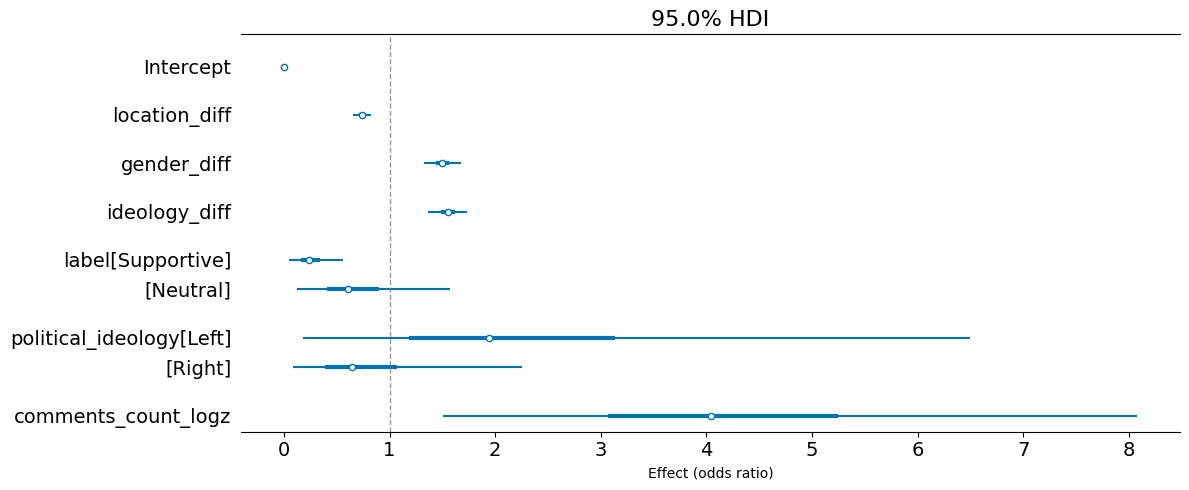

In [56]:
model = bmb.Model(
    "presence_no_rank ~ location_diff + gender_diff + ideology_diff + political_ideology + label + comments_count_logz + (1|urlid) + (1|comment)",
    data=reg_df,
    family="bernoulli",
    dropna=True,
)

results = model.fit(
    draws=2000,      
    tune=2000,       
    target_accept=0.97,
    chains=4,
    cores=4,
    random_seed=42,
    weights = reg_df['weights']
)

var_names = ['Intercept', 'location_diff', 'gender_diff', 'ideology_diff', 'label', 'political_ideology',  'comments_count_logz']
display(az.summary(results, var_names=var_names))

axes = az.plot_forest(
    results,
    combined=True,
    hdi_prob=0.95,
    transform=np.exp,
    figsize=(12, 5),
    r_hat=False,
    ess=False,
    var_names=var_names
)

ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes

ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
ax.set_xlabel("Effect (odds ratio)")
plt.tight_layout()
plt.show()

Modeling the probability that presence_no_rank==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, location_diff, gender_diff, ideology_diff, political_ideology, label, comments_count_logz, 1|urlid_sigma, 1|urlid_offset, 1|comment_sigma, 1|comment_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 1102 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-5.875,0.734,-7.251,-4.492,0.010,0.008,5747.0,5612.0,1.0
location_diff[Yes],-0.306,0.059,-0.416,-0.194,0.000,0.001,17378.0,5786.0,1.0
gender_diff[Yes],0.406,0.060,0.289,0.514,0.000,0.001,19023.0,6253.0,1.0
ideology_diff[Yes],0.439,0.062,0.319,0.553,0.000,0.001,18257.0,5994.0,1.0
label[Supportive],-1.455,0.533,-2.472,-0.485,0.009,0.006,3840.0,4885.0,1.0
label[Neutral],-0.499,0.576,-1.595,0.580,0.009,0.006,3879.0,4913.0,1.0
political_ideology[Left],0.656,0.727,-0.724,2.043,0.008,0.008,9056.0,6434.0,1.0
political_ideology[Right],-0.440,0.751,-1.787,1.034,0.008,0.008,8121.0,5521.0,1.0
comments_count_logz,1.391,0.404,0.651,2.178,0.006,0.004,4999.0,5219.0,1.0


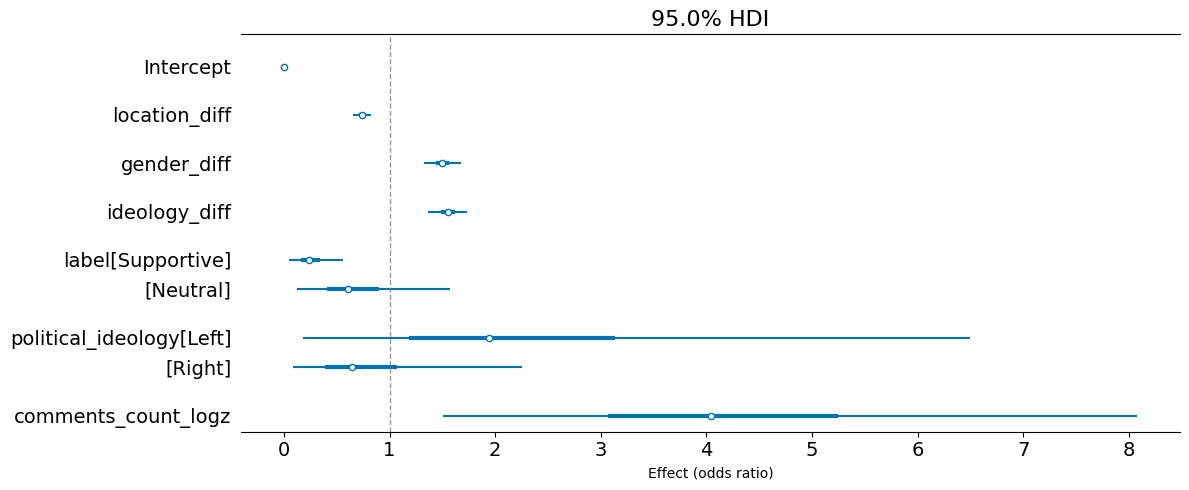

In [57]:
model = bmb.Model(
    "presence_no_rank ~ location_diff + gender_diff + ideology_diff + political_ideology + label + comments_count_logz + (1|urlid) + (1|comment)",
    data=reg_df,
    family="bernoulli",
    dropna=True,
)

results = model.fit(
    draws=2000,      
    tune=2000,       
    target_accept=0.97,
    chains=4,
    cores=4,
    random_seed=42,
    # weights = reg_df['weights']
)

var_names = ['Intercept', 'location_diff', 'gender_diff', 'ideology_diff', 'label', 'political_ideology',  'comments_count_logz']
display(az.summary(results, var_names=var_names))

axes = az.plot_forest(
    results,
    combined=True,
    hdi_prob=0.95,
    transform=np.exp,
    figsize=(12, 5),
    r_hat=False,
    ess=False,
    var_names=var_names
)

ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes

ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
ax.set_xlabel("Effect (odds ratio)")
plt.tight_layout()
plt.show()

#### combined

In [51]:
for col in ["posts", "followers", "following", "comments_count"]:
    new_col = col + "_logz"
    x = np.log1p(concat_df[col].astype(float))
    concat_df[new_col] = (x - x.mean()) / x.std()

concat_df["gender"] = pd.Categorical(
    concat_df["gender"],
    categories=["female_female", "male_male", "female_male"],
    ordered=True
)

concat_df["ideology"] = pd.Categorical(
    concat_df["ideology"],
    categories=["dem_dem", "rep_rep", "dem_rep"],
    ordered=True
)

concat_df["location"] = pd.Categorical(
    concat_df["location"],
    categories=["ny_ny", "texas_texas", "ny_texas"],
    ordered=True
)

concat_df['type'] = pd.Categorical(
    concat_df['type'],
    categories=['Non-News', 'News'],
    ordered=True
)

concat_df["gender_diff"] = pd.Categorical(
    concat_df["gender_diff"],
    categories=["No", "Yes"],
    ordered=True
)

concat_df["ideology_diff"] = pd.Categorical(
    concat_df["ideology_diff"],
    categories=["No", "Yes"],
    ordered=True
)

concat_df["location_diff"] = pd.Categorical(
    concat_df["location_diff"],
    categories=["No", "Yes"],
    ordered=True
)

# concat_df['presence_no_rank'] = pd.Categorical(
#     concat_df["presence_no_rank"],
#     categories=["No", "Yes"],
#     ordered=True
# )

concat_df['label'] = pd.Categorical(
    concat_df["label"],
    # categories=["Right leaning", "Neutral", "Left leaning"],
    categories=["Against", "Supportive", "Neutral"],
    ordered=True
)

In [52]:
url_pair_counts = (
    concat_df[['urlid', 'pair_id']]
    .value_counts()
    .reset_index(name='count')
)

url_pair_counts

concat_df = pd.merge(concat_df, url_pair_counts, on=['urlid', 'pair_id'], how='outer')
concat_df['weights'] = 1/concat_df['count']

In [53]:
concat_df.shape

(48603, 32)

In [54]:
nonnews_df[['account', 'urlid', 'comment_num']].duplicated().sum()

np.int64(0)

In [55]:
concat_df

,location,gender,ideology,setup_a,setup_b,pair_id,urlid,account,comment,presence_no_rank,presence_rank,label,main_topic,political_ideology,reporting_quality,credibility,posts,followers,following,comments_count,likes_count,gender_diff,location_diff,ideology_diff,type,Unnamed: 0,posts_logz,followers_logz,following_logz,comments_count_logz,count,weights
0,ny_texas,female_female,dem_dem,female_dem_ny_1,female_dem_texas_1,female_dem_ny_1_female_dem_texas_1,DR-_MPRkurr,catloversclub,"('meygya', 'Mujaer betina kah ? 😹😹')",0.0,NaN,Neutral,NaN,NaN,NaN,NaN,11718.0,8000000.0,1.0,190.0,49200.0,No,Yes,No,Non-News,229.0,0.129948,0.51351,-3.278337,-0.096860,10.0,0.100000
1,ny_texas,female_female,dem_dem,female_dem_ny_1,female_dem_texas_1,female_dem_ny_1_female_dem_texas_1,DR-_MPRkurr,catloversclub,"('andrea_regis_motociclistacgpb', 'Tinha uma a...",0.0,NaN,Neutral,NaN,NaN,NaN,NaN,11718.0,8000000.0,1.0,190.0,49200.0,No,Yes,No,Non-News,230.0,0.129948,0.51351,-3.278337,-0.096860,10.0,0.100000
2,ny_texas,female_female,dem_dem,female_dem_ny_1,female_dem_texas_1,female_dem_ny_1_female_dem_texas_1,DR-_MPRkurr,catloversclub,"('daisygizela', '😍😍')",0.0,NaN,Supportive,NaN,NaN,NaN,NaN,11718.0,8000000.0,1.0,190.0,49200.0,No,Yes,No,Non-News,231.0,0.129948,0.51351,-3.278337,-0.096860,10.0,0.100000
3,ny_texas,female_female,dem_dem,female_dem_ny_1,female_dem_texas_1,female_dem_ny_1_female_dem_texas_1,DR-_MPRkurr,catloversclub,"('susanrmz1', 'Uf papiti mio 😍')",0.0,NaN,Supportive,NaN,NaN,NaN,NaN,11718.0,8000000.0,1.0,190.0,49200.0,No,Yes,No,Non-News,232.0,0.129948,0.51351,-3.278337,-0.096860,10.0,0.100000
4,ny_texas,female_female,dem_dem,female_dem_ny_1,female_dem_texas_1,female_dem_ny_1_female_dem_texas_1,DR-_MPRkurr,catloversclub,"('karina.almeida.777', '🥰🥰🥰🥰🥰🙌🙏')",0.0,NaN,Supportive,NaN,NaN,NaN,NaN,11718.0,8000000.0,1.0,190.0,49200.0,No,Yes,No,Non-News,233.0,0.129948,0.51351,-3.278337,-0.096860,10.0,0.100000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48598,ny_texas,male_male,rep_rep,male_rep_ny_1,male_rep_texas_1,male_rep_ny_1_male_rep_texas_1,DSEn813Eo5Q,catloversclub,"('marleidegomes3', 'Coisa linda amo muito😍😍')",1.0,NaN,Supportive,NaN,NaN,NaN,NaN,11718.0,8000000.0,1.0,508.0,40700.0,No,Yes,No,Non-News,23786.0,0.129948,0.51351,-3.278337,0.552475,13.0,0.076923
48599,ny_texas,male_male,rep_rep,male_rep_ny_1,male_rep_texas_1,male_rep_ny_1_male_rep_texas_1,DSEn813Eo5Q,catloversclub,"('evallet', '❤️❤️❤️❤️❤️❤️❤️')",0.0,NaN,Supportive,NaN,NaN,NaN,NaN,11718.0,8000000.0,1.0,508.0,40700.0,No,Yes,No,Non-News,23787.0,0.129948,0.51351,-3.278337,0.552475,13.0,0.076923
48600,ny_texas,male_male,rep_rep,male_rep_ny_1,male_rep_texas_1,male_rep_ny_1_male_rep_texas_1,DSEn813Eo5Q,catloversclub,"('itsriisaaa', 'Lucuuu❤️')",1.0,NaN,Supportive,NaN,NaN,NaN,NaN,11718.0,8000000.0,1.0,508.0,40700.0,No,Yes,No,Non-News,23788.0,0.129948,0.51351,-3.278337,0.552475,13.0,0.076923
48601,ny_texas,male_male,rep_rep,male_rep_ny_1,male_rep_texas_1,male_rep_ny_1_male_rep_texas_1,DSEn813Eo5Q,catloversclub,"('naziraazizova80', '😍😍😍')",1.0,NaN,Supportive,NaN,NaN,NaN,NaN,11718.0,8000000.0,1.0,508.0,40700.0,No,Yes,No,Non-News,23789.0,0.129948,0.51351,-3.278337,0.552475,13.0,0.076923


In [56]:
formula = "presence_no_rank ~ gender_diff + location_diff + ideology_diff + C(label) + C(type) + comments_count_logz"  
get_vif(formula, concat_df)

,feature,VIF
2,location_diff[T.Yes],1.070668
3,ideology_diff[T.Yes],1.072495
1,gender_diff[T.Yes],1.075702
7,comments_count_logz,1.103800
6,C(type)[T.News],1.135661
5,C(label)[T.Neutral],1.496968
4,C(label)[T.Supportive],1.505058
0,Intercept,11.731024


Automatically removing 28/48603 rows from the dataset.
Modeling the probability that presence_no_rank==1
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [Intercept, location_diff, gender_diff, ideology_diff, label, comments_count_logz, type, 1|urlid_sigma, 1|urlid_offset, 1|comment_sigma, 1|comment_offset]


Output()

Sampling 2 chains for 800 tune and 800 draw iterations (1_600 + 1_600 draws total) took 1778 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-2.476,0.460,-3.280,-1.544,0.019,0.010,558.0,901.0,1.00
location_diff[Yes],-0.257,0.039,-0.328,-0.183,0.001,0.001,4013.0,1078.0,1.00
gender_diff[Yes],0.196,0.039,0.126,0.269,0.001,0.001,3229.0,1064.0,1.00
ideology_diff[Yes],0.103,0.038,0.029,0.172,0.001,0.001,3913.0,1035.0,1.00
label[Supportive],-2.015,0.382,-2.741,-1.299,0.018,0.010,473.0,818.0,1.00
label[Neutral],0.048,0.394,-0.642,0.853,0.018,0.010,466.0,629.0,1.01
type[News],-2.827,0.511,-3.721,-1.818,0.018,0.012,829.0,942.0,1.00
comments_count_logz,1.398,0.271,0.899,1.892,0.009,0.006,959.0,1139.0,1.00


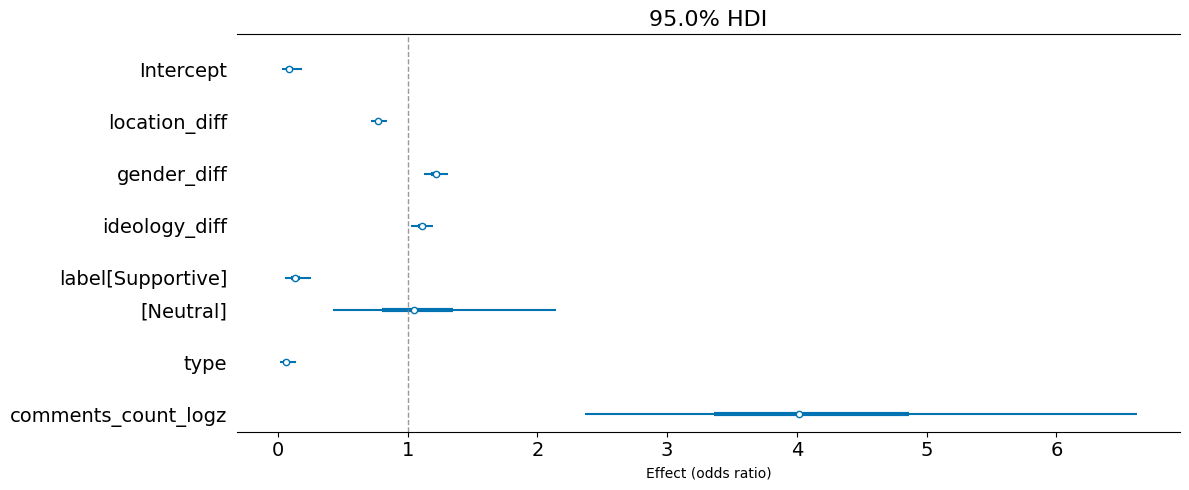

In [57]:
model = bmb.Model(
    "presence_no_rank ~ location_diff + gender_diff + ideology_diff + label + comments_count_logz + type + (1|urlid) + (1|comment)",
    data=concat_df,
    family="bernoulli",
    dropna=True,
)

results = model.fit(
    draws=800,      
    tune=800,       
    target_accept=0.97,
    chains=2,
    cores=1,
    random_seed=42,
    weights = concat_df['weights']
)

var_names = ['Intercept', 'location_diff', 'gender_diff', 'ideology_diff', 'label', 'type',  'comments_count_logz']
display(az.summary(results, var_names=var_names))

axes = az.plot_forest(
    results,
    combined=True,
    hdi_prob=0.95,
    transform=np.exp,
    figsize=(12, 5),
    r_hat=False,
    ess=False,
    var_names=var_names
)

ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes

ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
ax.set_xlabel("Effect (odds ratio)")
plt.tight_layout()
plt.show()

Automatically removing 28/48603 rows from the dataset.
Modeling the probability that presence_no_rank==1
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [Intercept, location_diff, gender_diff, ideology_diff, label, comments_count_logz, account, type, 1|urlid_sigma, 1|urlid_offset, 1|comment_sigma, 1|comment_offset]


Output()

Sampling 2 chains for 800 tune and 800 draw iterations (1_600 + 1_600 draws total) took 2155 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-2.505,0.524,-3.512,-1.562,0.022,0.012,559.0,844.0,1.00
location_diff[Yes],-0.258,0.038,-0.330,-0.189,0.001,0.001,3115.0,1160.0,1.00
gender_diff[Yes],0.197,0.038,0.118,0.265,0.001,0.001,3679.0,1012.0,1.00
ideology_diff[Yes],0.104,0.038,0.034,0.177,0.001,0.001,3377.0,1152.0,1.00
label[Supportive],-1.942,0.364,-2.584,-1.225,0.018,0.011,398.0,673.0,1.01
label[Neutral],0.066,0.409,-0.729,0.808,0.023,0.013,324.0,526.0,1.00
type[News],-2.631,0.582,-3.734,-1.576,0.021,0.014,818.0,1038.0,1.00
account[breitbart],0.267,0.762,-1.094,1.755,0.020,0.020,1426.0,1064.0,1.00
account[catloversclub],-1.223,0.764,-2.619,0.188,0.021,0.017,1314.0,1257.0,1.00
account[cnn],-0.341,0.751,-1.764,1.087,0.021,0.020,1243.0,1103.0,1.00


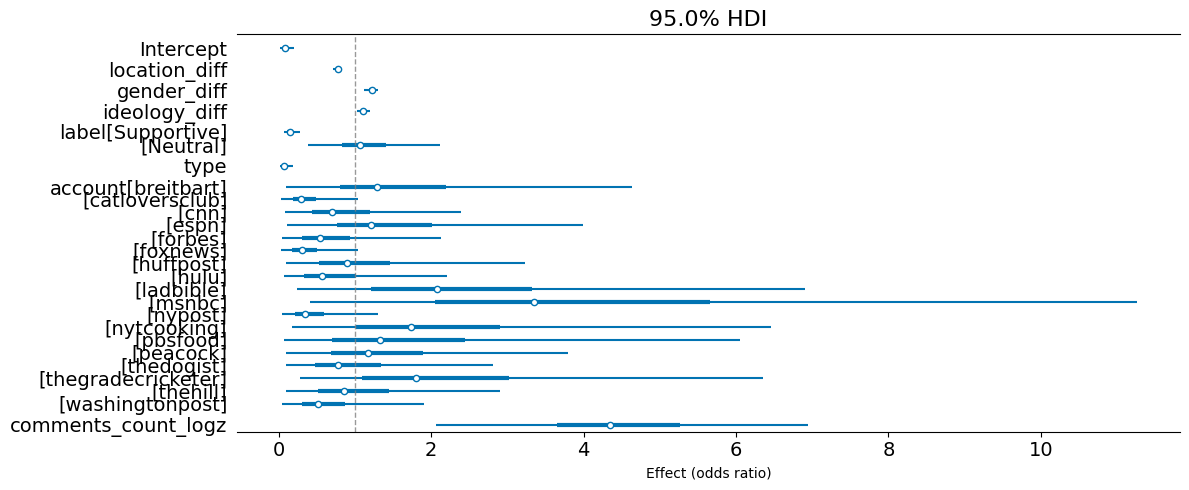

In [58]:
model = bmb.Model(
    "presence_no_rank ~ location_diff + gender_diff + ideology_diff + label + comments_count_logz + account + type + (1|urlid) + (1|comment)",
    data=concat_df,
    family="bernoulli",
    dropna=True,
)

results = model.fit(
    draws=800,      
    tune=800,       
    target_accept=0.97,
    chains=2,
    cores=1,
    random_seed=42,
    weights = concat_df['weights']
)

var_names = ['Intercept', 'location_diff', 'gender_diff', 'ideology_diff', 'label', 'type', 'account', 'comments_count_logz']
display(az.summary(results, var_names=var_names))

axes = az.plot_forest(
    results,
    combined=True,
    hdi_prob=0.95,
    transform=np.exp,
    figsize=(12, 5),
    r_hat=False,
    ess=False,
    var_names=var_names
)

ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes

ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
ax.set_xlabel("Effect (odds ratio)")
plt.tight_layout()
plt.show()

In [ ]:
model = bmb.Model(
    "presence_no_rank ~ location + gender + ideology + label + comments_count_logz + type + (1|urlid) + (1|comment)",
    data=concat_df,
    family="bernoulli",
    dropna=True,
)

results = model.fit(
    draws=800,      
    tune=800,       
    target_accept=0.97,
    chains=4,
    cores=1,
    random_seed=42,
    weights = concat_df['weights']
)

var_names = ['Intercept', 'location', 'gender', 'ideology', 'label', 'type', 'comments_count_logz']
display(az.summary(results, var_names=var_names))

axes = az.plot_forest(
    results,
    combined=True,
    hdi_prob=0.95,
    transform=np.exp,
    figsize=(12, 5),
    r_hat=False,
    ess=False,
    var_names=var_names
)

ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes

ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
ax.set_xlabel("Effect (odds ratio)")
plt.tight_layout()
plt.show()

Automatically removing 28/48603 rows from the dataset.
Modeling the probability that presence_no_rank==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, location, gender, ideology, label, comments_count_logz, type, 1|urlid_sigma, 1|urlid_offset, 1|comment_sigma, 1|comment_offset]


Output()

EOFError: 